In [2]:
# загружаем сбалансированный корпус

import pandas as pd

df = pd.read_csv('../data/chatgpt_reviews_clean_balanced.csv')

In [ ]:
!pip install scikit-learn 

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 5.8 MB/s  0:00:03 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [3]:
#импортируем TF IDF и создаем объект, удаляем англ стоп слова, лимит в 5000 слов

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

#читаем корпус, строим словарь, считаем IDF
X = vectorizer.fit_transform(df['content'].astype(str))

In [ ]:
#X.shape
#X[0]
#vectorizer.get_feature_names_out()

array(['00', '083', '10', ..., 'مننہi', 'अड', 'रह'],
      shape=(5000,), dtype=object)

In [11]:
#считаем симиларити между отзывами
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

In [17]:
#посмотрим на матрицу

#similarity_matrix.shape
#similarity_matrix[:5, :5]
similarity_matrix[0]

array([1.        , 0.        , 0.        , ..., 0.42349971, 0.        ,
       0.        ], shape=(4620,))

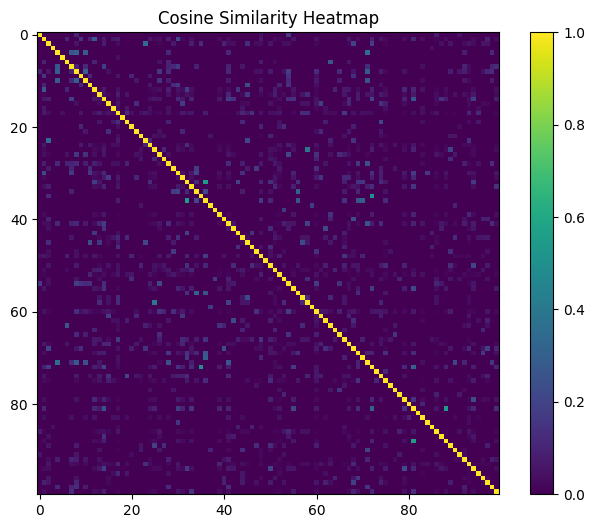

In [16]:
#посмотрим на heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    similarity_matrix[:100, :100],
    cmap='viridis'
)

plt.colorbar()

plt.title('Cosine Similarity Heatmap')

plt.show()

In [22]:
#делаем поиск похожих отзывов

import numpy as np

review_index = 10
similarities = similarity_matrix[review_index]

# самые похожие
similar_indices = np.argsort(similarities)[::-1][1:6]

print("Исходный отзыв:\n")
print(df.iloc[review_index]['content'])

print("\nПохожие отзывы:\n")

for idx in similar_indices:
    print('-' * 50)
    print(df.iloc[idx]['content'])

Исходный отзыв:

I can't remove the popup that says I've reached the free limit for chats with images and it annoys me while I'm reading the conversation.

Похожие отзывы:

--------------------------------------------------
always says I've reached daily limit even though I haven't used it 🫩🙅‍♀️
--------------------------------------------------
I am just starting to use and say the limit is reached for chats
--------------------------------------------------
when I needed it most it says you have reached your limit....duhhhhh
--------------------------------------------------
but have got limit chats
--------------------------------------------------
Nice , you should expand free limit


In [23]:
# создаём маску для негативных отзывов (оценки 1 и 2)
# получится массив True/False:
# True — отзыв негативный
# False — отзыв не относится к негативным
negative_mask = df['score'].isin([1, 2]).to_numpy()

# создаём маску для позитивных отзывов (оценки 4 и 5)
positive_mask = df['score'].isin([4, 5]).to_numpy()

# выбираем из TF-IDF матрицы только негативные отзывы
# каждая строка матрицы соответствует одному отзыву
negative_tfidf = X[negative_mask]

# выбираем из TF-IDF матрицы только позитивные отзывы
positive_tfidf = X[positive_mask]

In [24]:
# получаем список всех слов (признаков),
# которые вошли в TF-IDF словарь

feature_names = vectorizer.get_feature_names_out()

# считаем средний TF-IDF вес каждого слова
# среди всех негативных отзывов
#
# axis=0 → усреднение по столбцам (словам)
#
# .A1 → преобразование sparse matrix
# в обычный одномерный numpy array

negative_mean = negative_tfidf.mean(axis=0).A1

# сортируем слова по TF-IDF весу
#
# np.argsort() возвращает индексы слов
# от меньшего значения к большему
#
# [::-1] переворачивает порядок
# (от большего к меньшему)
#
# [:20] берём топ-20 самых важных слов
top_negative = np.argsort(negative_mean)[::-1][:20]

# выводим:
# (слово, средний TF-IDF вес)
#
# feature_names[i] → слово
# negative_mean[i] → его средний TF-IDF вес
[(feature_names[i], negative_mean[i]) for i in top_negative]

[('app', np.float64(0.04303982635083089)),
 ('ai', np.float64(0.024142624044733694)),
 ('wrong', np.float64(0.023698224846967257)),
 ('bad', np.float64(0.021909613989445843)),
 ('chat', np.float64(0.020730038696905134)),
 ('don', np.float64(0.01974590405667975)),
 ('time', np.float64(0.01968078224479915)),
 ('good', np.float64(0.019581210264751646)),
 ('like', np.float64(0.019446701262109303)),
 ('information', np.float64(0.018160589529889696)),
 ('chatgpt', np.float64(0.018063650609025143)),
 ('use', np.float64(0.017068392576989874)),
 ('answer', np.float64(0.01671392541164842)),
 ('just', np.float64(0.016139161878984138)),
 ('worst', np.float64(0.014025990756794874)),
 ('gpt', np.float64(0.01354466116982106)),
 ('answers', np.float64(0.013373919698363802)),
 ('doesn', np.float64(0.01261531653087195)),
 ('better', np.float64(0.012181537745024488)),
 ('want', np.float64(0.012145451458813345))]

In [25]:
positive_mean = positive_tfidf.mean(axis=0).A1

top_positive = np.argsort(positive_mean)[::-1][:20]

[(feature_names[i], positive_mean[i]) for i in top_positive]

[('app', np.float64(0.087052054727497)),
 ('good', np.float64(0.06511572988743951)),
 ('best', np.float64(0.057385980853827456)),
 ('helpful', np.float64(0.04351864490094638)),
 ('love', np.float64(0.03794236564377237)),
 ('useful', np.float64(0.0291174838014874)),
 ('nice', np.float64(0.029001204760925128)),
 ('chatgpt', np.float64(0.028240957317254827)),
 ('like', np.float64(0.023152308615904307)),
 ('ai', np.float64(0.02302575712328709)),
 ('great', np.float64(0.022256276837224774)),
 ('really', np.float64(0.020754916206175953)),
 ('use', np.float64(0.02038429647073855)),
 ('help', np.float64(0.019280198193433094)),
 ('chat', np.float64(0.018561028489265437)),
 ('helps', np.float64(0.01741772622033324)),
 ('amazing', np.float64(0.017347189838819665)),
 ('gpt', np.float64(0.01591801055969989)),
 ('easy', np.float64(0.013709362157591566)),
 ('students', np.float64(0.013085010773735485))]

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(X)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


In [27]:
df['cluster'].value_counts()

cluster
2    3362
1     697
4     291
3     204
0      66
Name: count, dtype: int64

In [28]:
import numpy as np

# слова TF-IDF
terms = vectorizer.get_feature_names_out()

# центры кластеров
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# топ слов
for i in range(5):
    print(f'\nCLUSTER {i}')
    
    top_words = [
        terms[ind]
        for ind in order_centroids[i, :15]
    ]
    
    print(', '.join(top_words))


CLUSTER 0
working, voice, properly, app, text, isn, good, application, update, chatgpt, time, speech, 100, nice, slow

CLUSTER 1
app, good, nice, helpful, love, useful, like, really, amazing, use, students, great, try, help, work

CLUSTER 2
chatgpt, ai, helpful, good, app, like, use, wrong, time, information, answer, just, don, useful, answers

CLUSTER 3
chat, gpt, good, app, best, love, helpful, thank, like, use, using, really, friend, ai, just

CLUSTER 4
best, app, ai, world, friend, love, chatgpt, used, far, apps, seen, good, aap, just, helpful


In [31]:
cluster_id = 2

sample_reviews = df[df['cluster'] == cluster_id]['content'].head(10)

for review in sample_reviews:
    print('-' * 80)
    print(review)

--------------------------------------------------------------------------------
I would give this 5 star, but one key flaw it knows what I say without me telling it and that's invasion of privacy
--------------------------------------------------------------------------------
This is a completely useless app. Don't download it if you want to waste your time
--------------------------------------------------------------------------------
used to be good and helpful but it is now all for the money. full of errors for just simple inquiries. also forcing you all the upgrade to paid higher version.
--------------------------------------------------------------------------------
fi7dhc 88 is le ga tx existing seats height ya q richh distal crystal hai ram custodial att exer hun dj gym dj xun dj bir guruv citiz iska
--------------------------------------------------------------------------------
when I needed it most it says you have reached your limit....duhhhhh
----------------------------

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [33]:
pca = PCA(n_components=2)

In [34]:
X_pca = pca.fit_transform(X.toarray())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/pyth

In [35]:
X_pca.shape

(4620, 2)

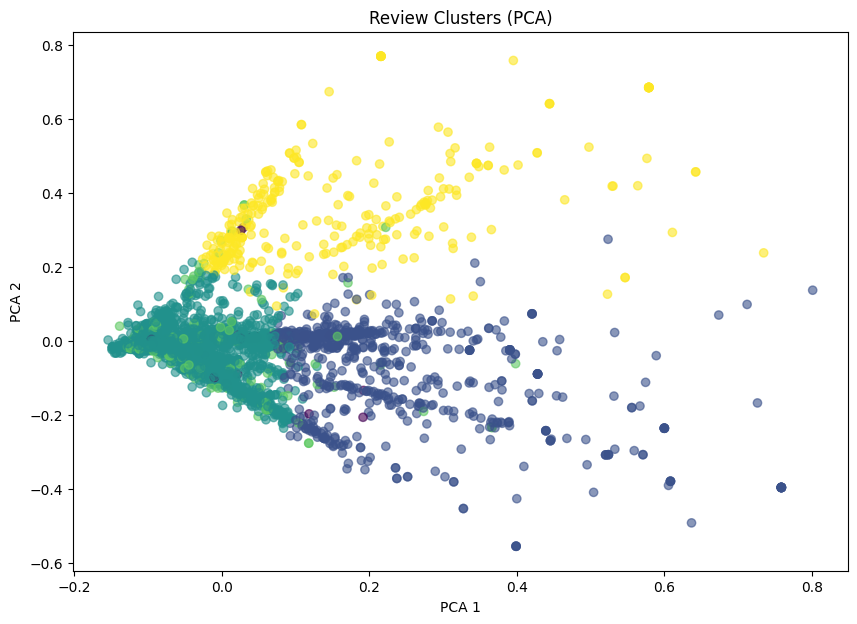

In [38]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    alpha=0.6
)

plt.title('Review Clusters (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()